In [2]:
# importação de Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
import shap;

/home/vcollares/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Carregando o dataSet
df = pd.read_parquet('dadosMinas/bdqueimadas_final.parquet')

In [4]:
# Criando dataframe apenas com dados do Cerrado
df_cerrado = df[df['Bioma'] == 'Cerrado'].copy()

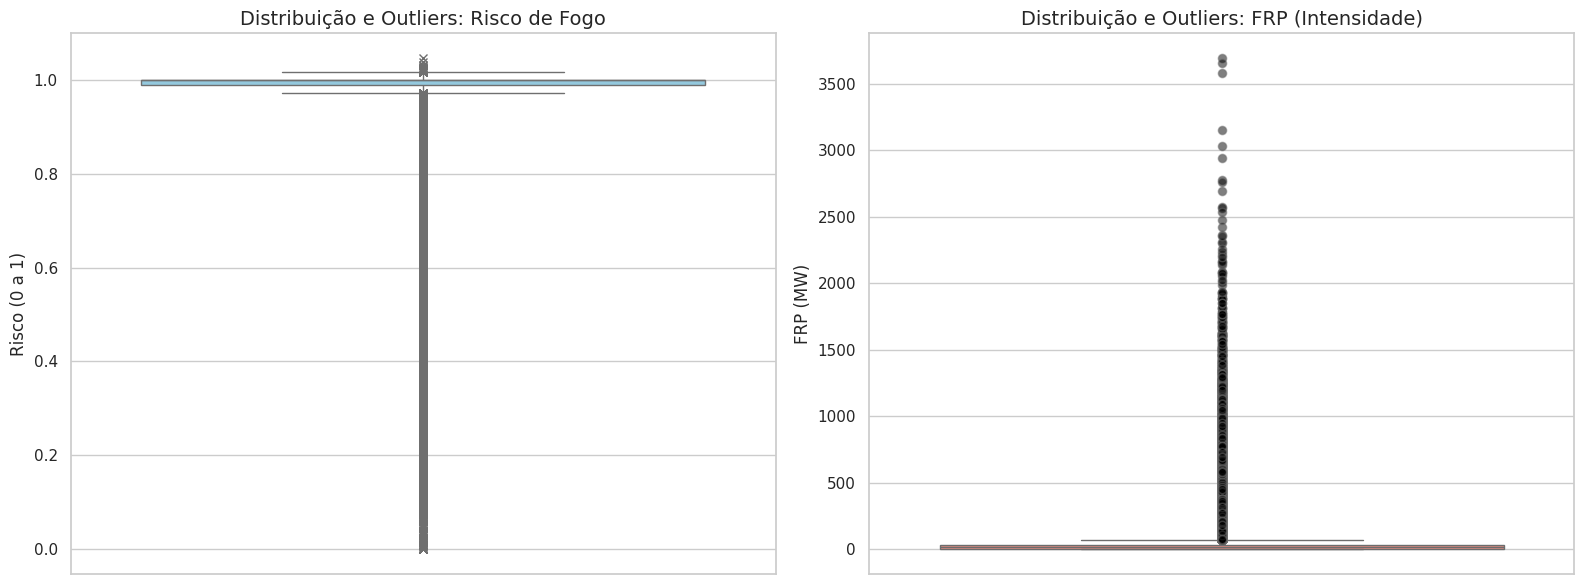

In [ ]:
# Gráfico de outliers dos foco do modelo
sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_cerrado['RiscoFogo'], color='skyblue', flierprops={"marker": "x", "markerfacecolor": "red"})
plt.title('Distribuição e Outliers: Risco de Fogo', fontsize=14)
plt.ylabel('Risco (0 a 1)', fontsize=12)


plt.tight_layout()
plt.show()

**IDEIA 1** 

Padronizar o modelo para ficar exatamente a mesma quantidade de valoes com risco fogo alto >= 8, e risco fogo baixo < 8.

In [ ]:
# Calcula a quantidade de linhas com RiscoFogo menor que 8 e do total do cerrado
total_abaixo_08 = (df_cerrado['RiscoFogo'] < 0.8).sum()
total_geral = len(df_cerrado)
percentual = (total_abaixo_08 / total_geral) * 100

print(f"Quantidade de focos com Risco de Fogo < 0.8: {total_abaixo_08}")
print(f"Total de registros no Cerrado: {total_geral}")
print(f"Isso representa {percentual:.2f}% do seu dataset!")

Quantidade de focos com Risco de Fogo < 0.8: 157786
Total de registros no Cerrado: 1310222
Isso representa 12.04% do seu dataset!


In [ ]:
# Cria um dataset temporario com todas as linhas com risco fogo baixo e as com a mesma quantidade de linhas de risco fogo alto, escolhido aleatoriamente.
df_risco_baixo = df_cerrado[df_cerrado['RiscoFogo'] < 0.8]
df_risco_alto = df_cerrado[df_cerrado['RiscoFogo'] >= 0.8]

df_risco_alto_amostra = df_risco_alto.sample(n=len(df_risco_baixo), random_state=42)

df_balanceado = pd.concat([df_risco_baixo, df_risco_alto_amostra])

df_balanceado = df_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Novo tamanho do Dataset: {len(df_balanceado)} linhas")
print(f"Risco Baixo (<0.8): {len(df_balanceado[df_balanceado['RiscoFogo'] < 0.8])} linhas")
print(f"Risco Alto (>=0.8): {len(df_balanceado[df_balanceado['RiscoFogo'] >= 0.8])} linhas")

Novo tamanho do Dataset: 315572 linhas
Risco Baixo (<0.8): 157786 linhas
Risco Alto (>=0.8): 157786 linhas


In [ ]:
# Cria as variáveis que serão utilizadas no modelo
df_balanceado['DataHora'] = pd.to_datetime(df_balanceado['DataHora'])
df_balanceado['Mes'] = df_balanceado['DataHora'].dt.month
df_balanceado['Hora'] = df_balanceado['DataHora'].dt.hour

X = df_balanceado[['DiaSemChuva', 'Precipitacao', 'Temperatura_C', 'Umidade_Relativa_%', 'Vento_ms', 'Mes', 'Hora', 'Latitude', 'Longitude']]
y_binario = (df_balanceado['RiscoFogo'] >= 0.8).astype(int)

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y_binario, test_size=0.2, random_state=42)

In [ ]:
# Faz um gridSeach para a randomForest
param_grid_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 15, 20], 
    'min_samples_split': [5, 10], 
    'min_samples_leaf': [2, 4]    
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=3,
    scoring='accuracy',
    verbose=2, 
    n_jobs=-1
)

grid_rf.fit(X_treino, y_treino)

print(f"Melhores Parâmetros RF: {grid_rf.best_params_}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits


[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=  48.9s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  55.3s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  57.5s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time= 1.0min
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time= 1.0min
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time= 1.1min
[CV] END max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=  39.2s
[CV] END max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=  46.5s
[CV] END max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=  54.5s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total 

In [ ]:
# Faz o GridSearch com o xgboost
param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0] 
}

xgb_base = XGBClassifier(tree_method='hist', random_state=42, n_jobs=-1)

grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

grid_xgb.fit(X_treino, y_treino)

print(f"Melhores Parâmetros XGB: {grid_xgb.best_params_}")

Fitting 3 folds for each of 192 candidates, totalling 576 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   4.8s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   4.8s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   4.9s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=1.0; total time=   5.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=1.0; total time=   5.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=1.0; total time=   5.7s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=0.8; total time=   5.5s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=0.8; total time=   5.2s
[CV] END 

/home/vcollares/.venv/lib64/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=1.0; total time=   5.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=0.8; total time=  17.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=1.0; total time=  17.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=0.8; total time=  17.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=0.8; total time=  17.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=1.0; total time=  13.5s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=500, subsample=1.0; total time=  13.7s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=8, n_estimators=100, subsample=0.8; total time=   6.9s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estima

Acurácia FINAL Random Forest (Limiar 30%): 92.31%



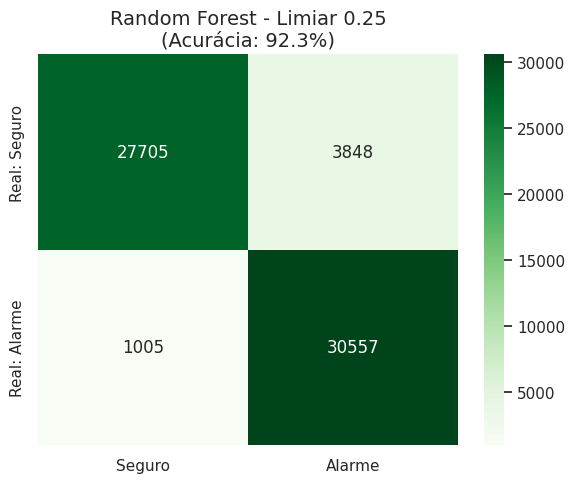

In [ ]:
# Treina o modelo a partir do melhores parametros encontrados pelo GridSearch
modelo_rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

modelo_rf_final.fit(X_treino, y_treino)

limiar = 0.25
probabilidades_rf = modelo_rf_final.predict_proba(X_teste)[:, 1]
previsoes_rf_medrosas = (probabilidades_rf >= limiar).astype(int)

acc_rf = accuracy_score(y_teste, previsoes_rf_medrosas)
print(f"Acurácia FINAL Random Forest (Limiar 25%): {acc_rf * 100:.2f}%\n")

plt.figure(figsize=(6, 5))
matriz_rf = confusion_matrix(y_teste, previsoes_rf_medrosas)
sns.heatmap(matriz_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Seguro', 'Alarme'], yticklabels=['Real: Seguro', 'Real: Alarme'])
plt.title(f'Random Forest - Limiar {limiar}\n(Acurácia: {acc_rf*100:.1f}%)', fontsize=14)
plt.tight_layout()
plt.show()

Acurácia FINAL XGBoost (Limiar 25%): 94.61%



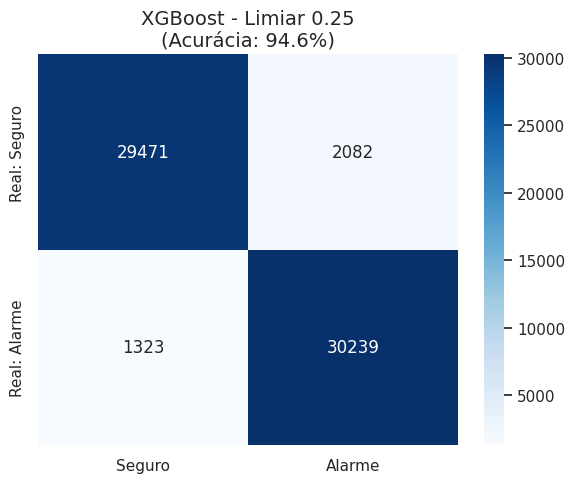

In [ ]:
#teste com o limiar 25%
modelo_xgb_final = XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.2,
    subsample=0.8,
    colsample_bytree=1.0,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

modelo_xgb_final.fit(X_treino, y_treino)

limiar = 0.25
probabilidades_xgb = modelo_xgb_final.predict_proba(X_teste)[:, 1]
previsoes_xgb_medrosas = (probabilidades_xgb >= limiar).astype(int)

acc_xgb = accuracy_score(y_teste, previsoes_xgb_medrosas)
print(f"Acurácia FINAL XGBoost (Limiar 25%): {acc_xgb * 100:.2f}%\n")

plt.figure(figsize=(6, 5))
matriz_xgb = confusion_matrix(y_teste, previsoes_xgb_medrosas)
sns.heatmap(matriz_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Seguro', 'Alarme'], yticklabels=['Real: Seguro', 'Real: Alarme'])
plt.title(f'XGBoost - Limiar {limiar}\n(Acurácia: {acc_xgb*100:.1f}%)', fontsize=14)
plt.tight_layout()
plt.show()

Acurácia FINAL Random Forest (Limiar 25%): 89.83%



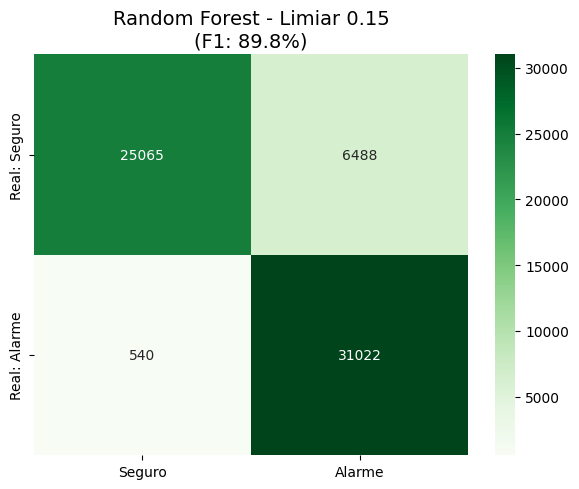

In [ ]:
# Teste com o Limiar 25%
modelo_rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

modelo_rf_final.fit(X_treino, y_treino)

limiar = 0.15
probabilidades_rf = modelo_rf_final.predict_proba(X_teste)[:, 1]
previsoes_rf_medrosas = (probabilidades_rf >= limiar).astype(int)

acc_rf = f1_score(y_teste, previsoes_rf_medrosas)
print(f"Acurácia FINAL Random Forest (Limiar 25%): {acc_rf * 100:.2f}%\n")

plt.figure(figsize=(6, 5))
matriz_rf = confusion_matrix(y_teste, previsoes_rf_medrosas)
sns.heatmap(matriz_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Seguro', 'Alarme'], yticklabels=['Real: Seguro', 'Real: Alarme'])
plt.title(f'Random Forest - Limiar {limiar}\n(F1: {acc_rf*100:.1f}%)', fontsize=14)
plt.tight_layout()
plt.show()

**Ideia 2**

Usar o banco completo apesar da diferenca de quantidade de dados de riscoFogo alto e baixo

In [5]:
# Cria as variáveis do modelo
df_cerrado['DataHora'] = pd.to_datetime(df_cerrado['DataHora'])
df_cerrado['Mes'] = df_cerrado['DataHora'].dt.month
df_cerrado['Hora'] = df_cerrado['DataHora'].dt.hour

X = df_cerrado[['DiaSemChuva', 'Precipitacao', 'Temperatura_C', 'Umidade_Relativa_%', 'Vento_ms', 'Mes', 'Hora', 'Latitude', 'Longitude']]
y_binario = (df_cerrado['RiscoFogo'] >= 0.8).astype(int)

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y_binario, 
    test_size=0.2, 
    stratify=y_binario, 
    random_state=42
)

Acurácia FINAL Random Forest (Limiar 25%): 96.58%



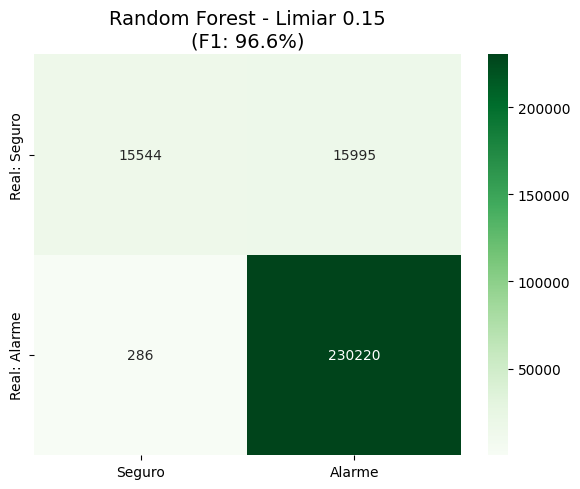

In [ ]:
# Treina o RandomForest
modelo_rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

modelo_rf_final.fit(X_treino, y_treino)

limiar = 0.15
probabilidades_rf = modelo_rf_final.predict_proba(X_teste)[:, 1]
previsoes_rf_medrosas = (probabilidades_rf >= limiar).astype(int)

acc_rf = f1_score(y_teste, previsoes_rf_medrosas)
print(f"Acurácia FINAL Random Forest (Limiar 25%): {acc_rf * 100:.2f}%\n")

plt.figure(figsize=(6, 5))
matriz_rf = confusion_matrix(y_teste, previsoes_rf_medrosas)
sns.heatmap(matriz_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Seguro', 'Alarme'], yticklabels=['Real: Seguro', 'Real: Alarme'])
plt.title(f'Random Forest - Limiar {limiar}\n(F1: {acc_rf*100:.1f}%)', fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
# GridSearch para decidir qual o melhor limiar para usar
modelo_xgb_final = XGBClassifier(
    subsample = 0.85,
    reg_lambda = 1, 
    reg_alpha = 0.1,
    n_estimators = 400,
    min_child_weight = 3, 
    max_depth = 8, 
    learning_rate= 0.1, 
    gamma = 1, 
    colsample_bytree = 1.0,
    random_state=42
)

modelo_xgb_final.fit(X_treino, y_treino)

probabilidades = modelo_xgb_final.predict_proba(X_teste)[:, 1]

limiares_para_testar = [0.01, 0.05, 0.10, 0.15, 0.16, 0.17, 0.18, 0.185, 0.19, 0.20, 0.21, 0.22, 0.23, 0.24, 0.25, 0.30, 0.40, 0.50]

resultados = []

for limiar in limiares_para_testar:
    previsoes = (probabilidades >= limiar).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_teste, previsoes).ravel()
    
    f1 = f1_score(y_teste, previsoes)

    resultados.append({
        "Limiar": f"{limiar:.4f}",
        "Falsos Negativos (Fogo Omitido) ": fn,
        "Falsos Positivos (Alarme à toa) ": fp,
        "F1-Score": f"{f1:.4f}"
    })

tabela_limiares = pd.DataFrame(resultados)

display(tabela_limiares)

,Limiar,Falsos Negativos (Fogo Omitido),Falsos Positivos (Alarme à toa),F1-Score
0,0.0100,6,29568,0.9397
1,0.0500,80,23620,0.9511
2,0.1000,270,19629,0.9586
3,0.1500,469,16766,0.9639
4,0.1600,533,16277,0.9647
5,0.1700,598,15837,0.9655
6,0.1800,663,15400,0.9662
7,0.1850,691,15172,0.9666
8,0.1900,725,14973,0.9670
9,0.2000,784,14572,0.9677



 XGBoost (Limiar 15.00%):
 - F1-Score:  96.39%
 - Recall:    99.80% (Fogo encontrado)
 - Precision: 93.21% (Alarmes corretos)



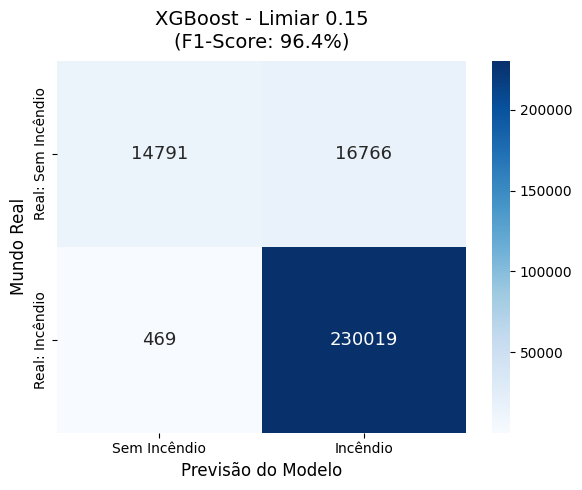

In [6]:
# Treinando o xgBoost com todos os melhores valores
modelo_xgb_final = XGBClassifier(
    subsample = 0.85,
    reg_lambda = 1, 
    reg_alpha = 0.1,
    n_estimators = 400,
    min_child_weight = 3, 
    max_depth = 8, 
    learning_rate = 0.1, 
    gamma = 1, 
    colsample_bytree = 1.0,
    random_state = 42,
    tree_method = 'hist',
    n_jobs = -1
)

modelo_xgb_final.fit(X_treino, y_treino)

limiar = 0.15
probabilidades_xgb = modelo_xgb_final.predict_proba(X_teste)[:, 1]
previsoes_xgb_medrosas = (probabilidades_xgb >= limiar).astype(int)

f1_xgb = f1_score(y_teste, previsoes_xgb_medrosas)
recall_xgb = recall_score(y_teste, previsoes_xgb_medrosas)
precisao_xgb = precision_score(y_teste, previsoes_xgb_medrosas)

print(f"\n XGBoost (Limiar {limiar*100:.2f}%):")
print(f" - F1-Score:  {f1_xgb * 100:.2f}%") 
print(f" - Recall:    {recall_xgb * 100:.2f}% (Fogo encontrado)")
print(f" - Precision: {precisao_xgb * 100:.2f}% (Alarmes corretos)\n")

plt.figure(figsize=(6, 5))
matriz_xgb = confusion_matrix(y_teste, previsoes_xgb_medrosas)

sns.heatmap(matriz_xgb, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 13},
            xticklabels=['Sem Incêndio', 'Incêndio'], 
            yticklabels=['Real: Sem Incêndio', 'Real: Incêndio'])

plt.title(f'XGBoost - Limiar {limiar}\n(F1-Score: {f1_xgb*100:.1f}%)', fontsize=14, pad=10)
plt.ylabel('Mundo Real', fontsize=12)
plt.xlabel('Previsão do Modelo', fontsize=12)
plt.tight_layout()
plt.show()


Gráfico 1: O que mais causa incêndio no Cerrado? (Importância Global)


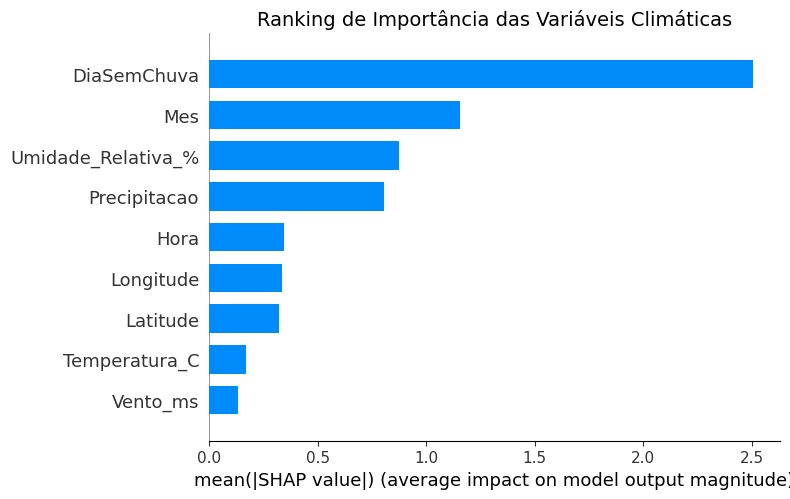


Gráfico 2: Como o clima afeta a decisão? (Vermelho vs Azul)


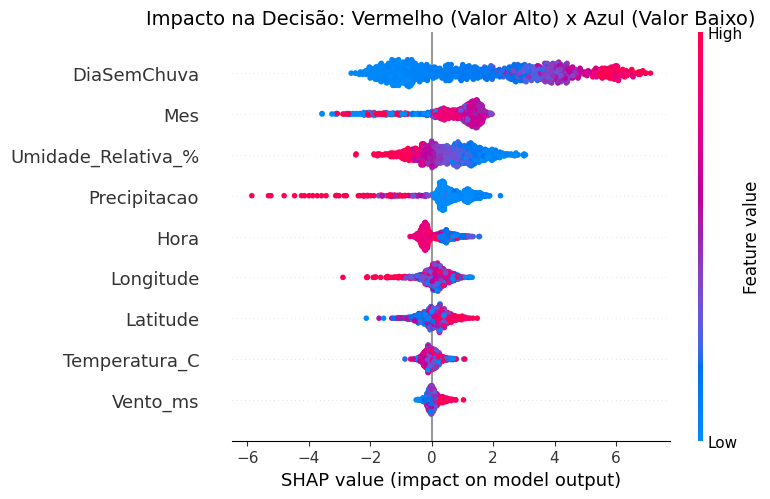


A variável número #1 para prever fogo foi: **DiaSemChuva**
Em segundo lugar: **Mes**


In [26]:
# Gráfico para ver a importância das variáveis.
X_amostra_shap = X_teste.sample(n=1000, random_state=42)

explainer = shap.TreeExplainer(modelo_xgb_final)
valores_shap = explainer.shap_values(X_amostra_shap)

print("\nGráfico 1: O que mais causa incêndio no Cerrado? (Importância Global)")
plt.figure(figsize=(10, 6))
shap.summary_plot(valores_shap, X_amostra_shap, plot_type="bar", show=False)
plt.title("Ranking de Importância das Variáveis Climáticas", fontsize=14)
plt.tight_layout()
plt.show()

print("\nGráfico 2: Como o clima afeta a decisão? (Vermelho vs Azul)")
plt.figure(figsize=(10, 6))
shap.summary_plot(valores_shap, X_amostra_shap, show=False)
plt.title("Impacto na Decisão: Vermelho (Valor Alto) x Azul (Valor Baixo)", fontsize=14)
plt.tight_layout()
plt.show()

importancia_media = np.abs(valores_shap).mean(axis=0)
indices_top_2 = np.argsort(importancia_media)[-2:][::-1]
variaveis_top_2 = X_amostra_shap.columns[indices_top_2].tolist()

print(f"\nA variável número #1 para prever fogo foi: **{variaveis_top_2[0]}**")
print(f"Em segundo lugar: **{variaveis_top_2[1]}**")

In [7]:
import joblib
joblib.dump(modelo_xgb_final, 'classificador_fogo_cerrado.pkl')

features_modelo = X.columns.tolist()
joblib.dump(features_modelo, 'features_fogo.pkl')

['features_fogo.pkl']